# Data Cleaning Pipeline
This notebook documents the cleaning process applied to the raw Keepa price history data.

## Cleaning decisions:
- **Forward-fill** missing prices up to 14 days (Keepa only records a new entry when a price change occurs, so short gaps represent days where the price was confirmed unchanged. The 14-day cap prevents filling across genuine out-of-stock or delisting periods where the product was not actually available)
- **Drop ASINs** with less than 365 days of history
- **Drop ASINs** with less than 200 valid rows after filling
- **Drop ASINs** with more than 60% missing after filling
- **Drop ASINs** with price std < 0.5 (completely flat prices — no buy-window signal)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.float_format', '{:.2f}'.format)

In [2]:
raw = pd.read_csv('../data/raw/all_asins_daily.csv', parse_dates=['date'])
print(f"Raw shape: {raw.shape}")
print(f"Raw ASINs: {raw['asin'].nunique()}")
print(f"Non-null prices: {raw['amazon_price'].notna().sum():,}")
print(f"Missing prices: {raw['amazon_price'].isna().sum():,} ({raw['amazon_price'].isna().mean()*100:.1f}%)")

Raw shape: (1454503, 6)
Raw ASINs: 618
Non-null prices: 252,356
Missing prices: 1,202,147 (82.7%)


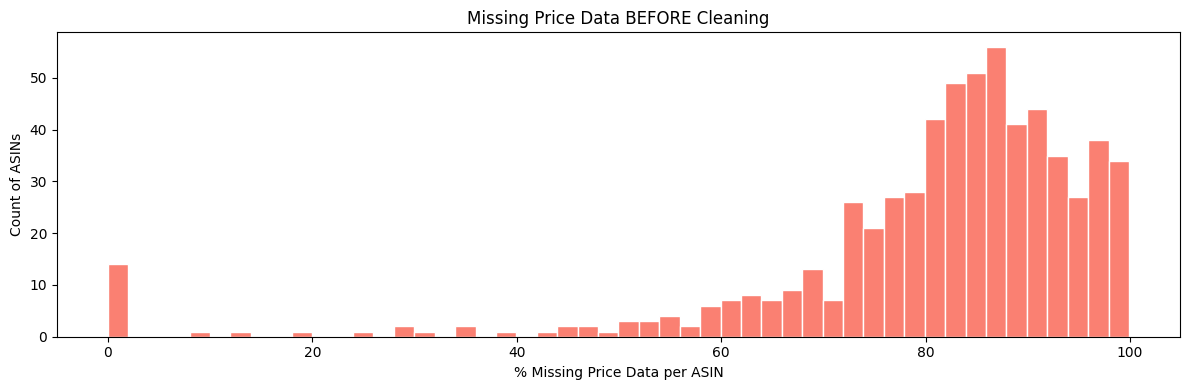

ASINs with >80% missing: 415
ASINs with >60% missing: 570
ASINs with <20% missing: 17


In [3]:
missing_before = raw.groupby('asin')['amazon_price'].apply(lambda x: x.isna().mean() * 100)

plt.figure(figsize=(12, 4))
plt.hist(missing_before, bins=50, color='salmon', edgecolor='white')
plt.xlabel('% Missing Price Data per ASIN')
plt.ylabel('Count of ASINs')
plt.title('Missing Price Data BEFORE Cleaning')
plt.tight_layout()
plt.show()

print(f"ASINs with >80% missing: {(missing_before > 80).sum()}")
print(f"ASINs with >60% missing: {(missing_before > 60).sum()}")
print(f"ASINs with <20% missing: {(missing_before < 20).sum()}")

In [4]:
df = raw.copy().sort_values(['asin', 'date'])
df['amazon_price'] = df.groupby('asin')['amazon_price'].transform(
    lambda x: x.ffill(limit=14)
)

missing_after = df.groupby('asin')['amazon_price'].apply(lambda x: x.isna().mean() * 100)

print("Missing data AFTER forward-fill:")
print(f"  ASINs with >80% missing: {(missing_after > 80).sum()}")
print(f"  ASINs with >60% missing: {(missing_after > 60).sum()}")
print(f"  ASINs with <20% missing: {(missing_after < 20).sum()}")

Missing data AFTER forward-fill:
  ASINs with >80% missing: 43
  ASINs with >60% missing: 114
  ASINs with <20% missing: 109


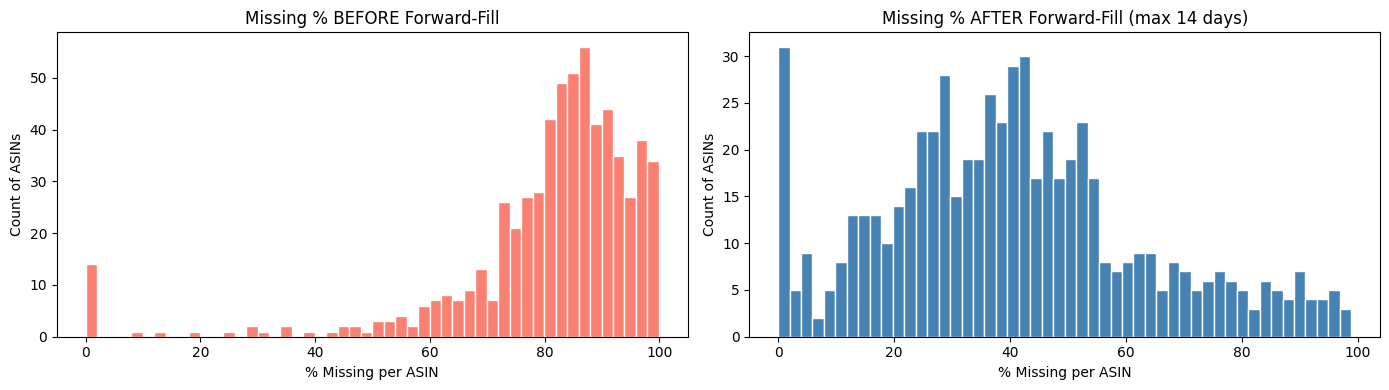

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(missing_before, bins=50, color='salmon', edgecolor='white')
axes[0].set_title('Missing % BEFORE Forward-Fill')
axes[0].set_xlabel('% Missing per ASIN')
axes[0].set_ylabel('Count of ASINs')

axes[1].hist(missing_after, bins=50, color='steelblue', edgecolor='white')
axes[1].set_title('Missing % AFTER Forward-Fill (max 14 days)')
axes[1].set_xlabel('% Missing per ASIN')
axes[1].set_ylabel('Count of ASINs')

plt.tight_layout()
plt.show()

In [6]:
asin_stats = df.groupby('asin').agg(
    total_rows   = ('amazon_price', 'count'),
    valid_rows   = ('amazon_price', lambda x: x.notna().sum()),
    missing_pct  = ('amazon_price', lambda x: x.isna().mean()),
    price_std    = ('amazon_price', 'std'),
    first_date   = ('date', 'min'),
    last_date    = ('date', 'max'),
).reset_index()

asin_stats['history_days'] = (asin_stats['last_date'] - asin_stats['first_date']).dt.days

mask = (
    (asin_stats['history_days'] >= 365) &
    (asin_stats['valid_rows']   >= 200) &
    (asin_stats['missing_pct']  <= 0.60) &
    (asin_stats['price_std']    >= 0.5)
)

good_asins = asin_stats[mask]['asin'].tolist()

print(f"ASINs passing all filters: {len(good_asins)}")
print(f"ASINs dropped: {(~mask).sum()}")
print(f"\nDrop reasons:")
print(f"  History < 365 days:    {(asin_stats['history_days'] < 365).sum()}")
print(f"  Valid rows < 200:      {(asin_stats['valid_rows'] < 200).sum()}")
print(f"  Missing > 60%:         {(asin_stats['missing_pct'] > 0.60).sum()}")
print(f"  Price std < 0.5:       {(asin_stats['price_std'] < 0.5).sum()}")

ASINs passing all filters: 458
ASINs dropped: 160

Drop reasons:
  History < 365 days:    62
  Valid rows < 200:      80
  Missing > 60%:         114
  Price std < 0.5:       10


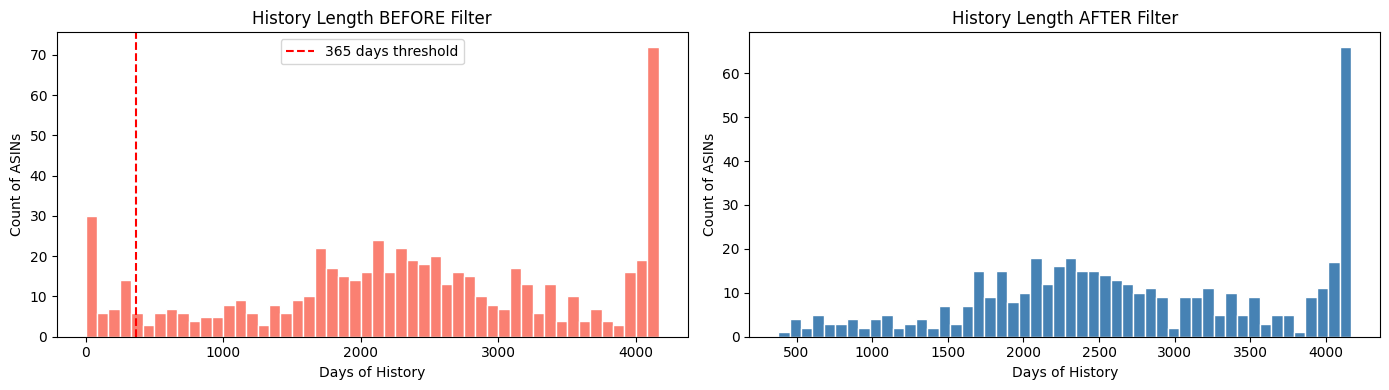

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(asin_stats['history_days'], bins=50, color='salmon', edgecolor='white')
axes[0].axvline(365, color='red', linestyle='--', label='365 days threshold')
axes[0].set_title('History Length BEFORE Filter')
axes[0].set_xlabel('Days of History')
axes[0].set_ylabel('Count of ASINs')
axes[0].legend()

good_stats = asin_stats[mask]
axes[1].hist(good_stats['history_days'], bins=50, color='steelblue', edgecolor='white')
axes[1].set_title('History Length AFTER Filter')
axes[1].set_xlabel('Days of History')
axes[1].set_ylabel('Count of ASINs')

plt.tight_layout()
plt.show()

In [8]:
clean = pd.read_csv('../data/processed/clean_data.csv', parse_dates=['date'])
print(f"Clean shape: {clean.shape}")
print(f"Clean ASINs: {clean['asin'].nunique()}")
print(f"Date range: {clean['date'].min()} to {clean['date'].max()}")
print(f"Price range: ${clean['amazon_price'].min():.2f} – ${clean['amazon_price'].max():.2f}")
print(f"Avg price: ${clean['amazon_price'].mean():.2f}")

Clean shape: (806086, 6)
Clean ASINs: 458
Date range: 2015-01-01 00:00:00 to 2026-05-31 00:00:00
Price range: $5.00 – $989.65
Avg price: $79.10


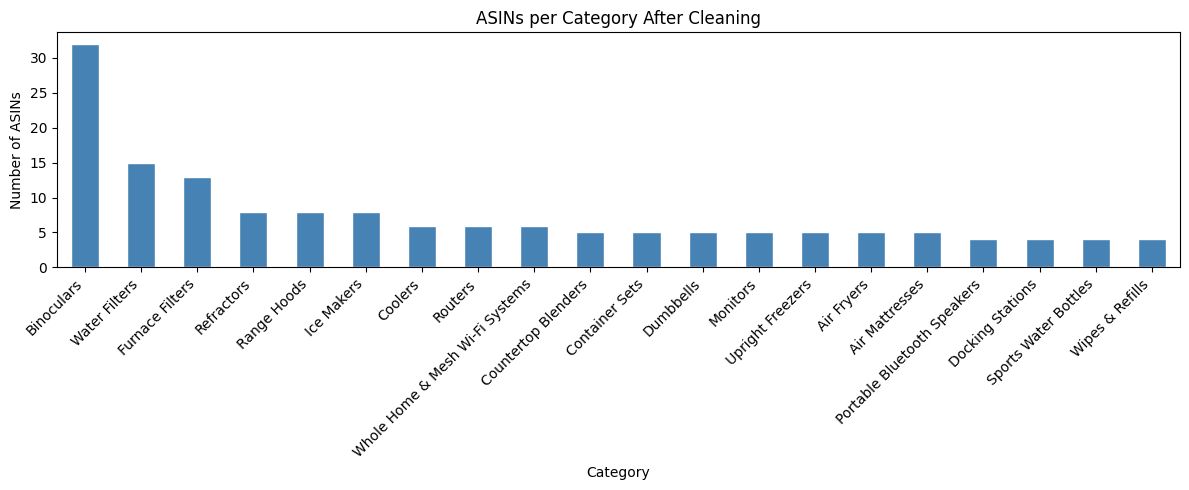

In [9]:
cat_dist = clean.groupby('category')['asin'].nunique().sort_values(ascending=False).head(20)

plt.figure(figsize=(12, 5))
cat_dist.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('ASINs per Category After Cleaning')
plt.xlabel('Category')
plt.ylabel('Number of ASINs')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

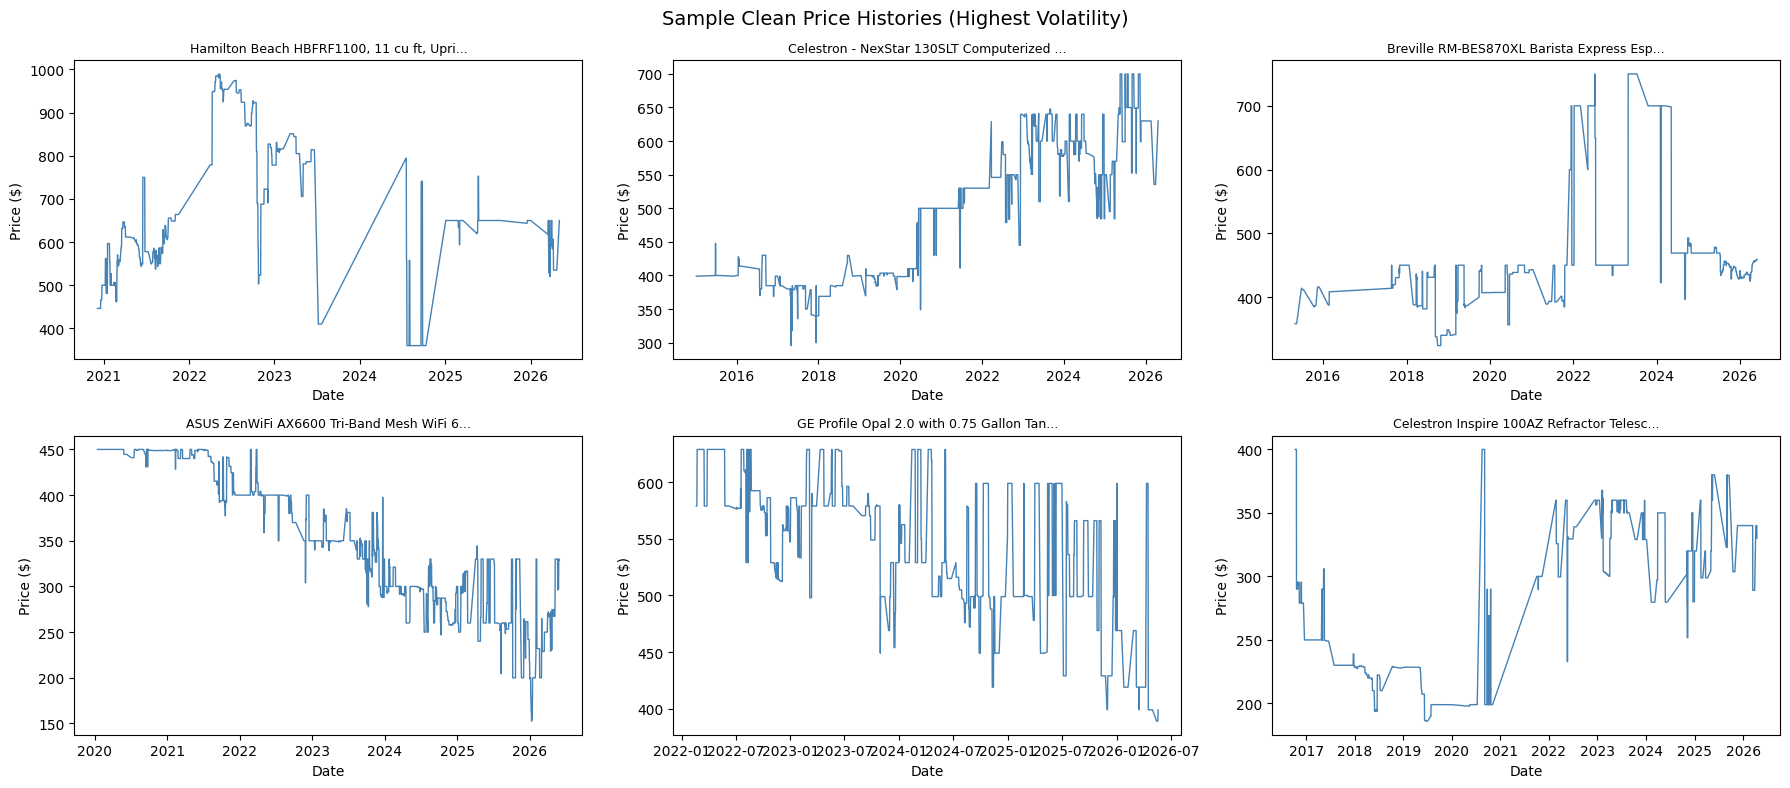

In [10]:
sample_asins = clean.groupby('asin')['amazon_price'].std().sort_values(ascending=False).head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
axes = axes.flatten()

for i, asin in enumerate(sample_asins):
    asin_df = clean[clean['asin'] == asin].set_index('date')['amazon_price']
    title = clean[clean['asin'] == asin]['title'].iloc[0][:40]
    axes[i].plot(asin_df.index, asin_df.values, linewidth=1, color='steelblue')
    axes[i].set_title(f"{title}...", fontsize=9)
    axes[i].set_xlabel('Date')
    axes[i].set_ylabel('Price ($)')

plt.suptitle('Sample Clean Price Histories (Highest Volatility)', fontsize=14)
plt.tight_layout()
plt.show()